In [52]:
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

import timesfm.timesfm_base as TFMbase
import timesfm.timesfm_torch as TFMtorch
import timesfm.data_loader as TFMDL
import timesfm.time_features as TFMtime
import timesfm.pytorch_patched_decoder as TFMmodel
import timesfm.custom_data_set as TFMdset

plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size': 14})
plt.rcParams['text.latex.preamble'] = r'\usepackage{times}'

device = torch.device('cuda:0')

In [53]:
# batch size
batch_size = 1024

# data
tcm = TFMbase.TimesFmHparams
tcm.per_core_batch_size = batch_size
tckpt = TFMbase.TimesFmCheckpoint(path='/home/sbose/timesfm/timesfm-1.0-200m-pytorch/torch_model.ckpt') # or load it directly from huggingface repo
base = TFMtorch.TimesFmTorch(tcm,tckpt)

In [54]:
# lookback and lookahead
lookback, lookahead = 96, 96

In [55]:
# get dataset
data = np.load('/home/sbose/out_there/FederatedPersonalizedLoadForecasting/NRELNYdataset.npz')['data'] # any comstock-style numpy matrix
dataset_train, dataset_val, dataset_test, mean, std = TFMdset.get_data_and_generate_train_val_test_sets(
    data_array = data,
    split_ratios = [0.8,0.1,0.1],
    dataset_kwargs = {
        'num_bldg' : data.shape[0],
        'lookback' : lookback,
        'lookahead' : lookahead,
        'normalize' : True,
        'dtype' : torch.float32,
        'context_len' : 512,
        'output_unpadded_inputs' : True
    }
)

In [61]:
# get dataloader
dl = DataLoader(dataset_train, batch_size = batch_size, shuffle=False)
dl_test = DataLoader(dataset_test, batch_size = batch_size, shuffle=False)

# move model to device
base._model = base._model.to(device)

In [62]:
# forecast using forward() for first item in batch
for itm in dl_test:
    ts, paddings, freq, _, x_unpadded = itm
    ts, paddings, freq = ts.to(device), paddings.to(device), freq.to(device)
    forecast_forward, _ = base._model.decode(
        ts,
        paddings,
        freq,
        horizon_len = lookahead
    )
    break

# move model back to CPU
base._model = base._model.to('cpu')

# forecast using api
forecast_input = [
    x_unpadded[0,:].numpy()
]
freq_input = [0]
forecast_api, _ = base.forecast(
    forecast_input,
    freq_input
)

In [63]:
# extach data
seq_lookback = x_unpadded[0,:].numpy()
seq_lookahead_forward = forecast_forward.detach().cpu().numpy()[0,:]
seq_lookahead_api = forecast_api[0,:lookahead]

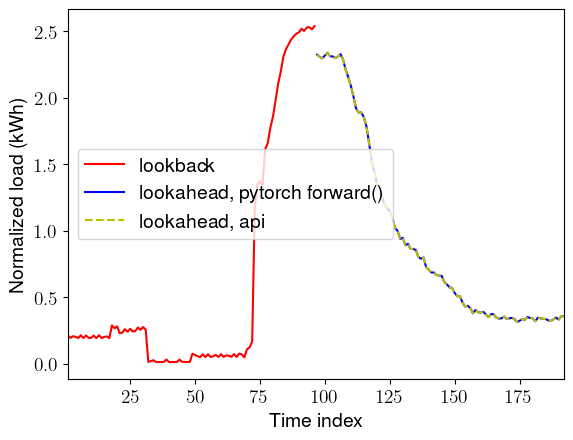

In [64]:
# plot
plt.plot(np.arange(1,lookback+1),seq_lookback,'r',label='lookback')
plt.plot(np.arange(lookback+1,lookback+lookahead+1),seq_lookahead_forward,'b',label='lookahead, pytorch forward()')
plt.plot(np.arange(lookback+1,lookback+lookahead+1),seq_lookahead_api,'y--',label='lookahead, api')
plt.xlim(1,lookback+lookahead)
plt.xlabel('Time index')
plt.ylabel('Normalized load (kWh)')
plt.legend()
plt.show()